In [1]:
!pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 9.7 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1


In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
import os

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
os.environ["OPENROUTER_API_KEY"]="api_key"

llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1"
)

In [4]:
class HealthcareState(TypedDict):

    symptoms: str
    patient_history: str

    extracted_symptoms: str
    risk_score: str
    medical_entities: str
    distress_analysis: str
    emergency_severity: str

    medical_guidelines: str
    drug_interactions: str
    similar_cases: str
    specialist_recommendations: str

    # ROUTING
    next_route: str
    assigned_specialist: str

    triage_summary: str
    followup_plan: str
    diagnostic_tests: str
    emergency_notification: str

    final_report: str

In [5]:
def extract_symptoms(state: HealthcareState):

    prompt = f"""
    You are a Clinical Symptom Extraction Agent.

    Analyze patient symptoms carefully.

    Extract:
    1. Primary symptoms
    2. Secondary symptoms
    3. Duration of symptoms
    4. Severity indicators
    5. Body systems affected

    Symptoms:
    {state['symptoms']}

    Return structured symptom analysis.
    """

    response = llm.invoke(prompt)

    return {
        "extracted_symptoms": response.content
    }

In [6]:
def risk_scoring(state: HealthcareState):

    prompt = f"""
    You are a Medical Risk Assessment Agent.

    Analyze patient condition.

    Determine:
    - Low Risk
    - Medium Risk
    - High Risk
    - Critical Emergency

    Evaluate:
    1. Symptom severity
    2. Duration
    3. Emergency indicators
    4. Urgency score (1-100)

    Symptoms:
    {state['symptoms']}

    Provide detailed reasoning.
    """

    response = llm.invoke(prompt)

    return {
        "risk_score": response.content
    }

In [7]:
def medical_entity_recognition(state: HealthcareState):

    prompt = f"""
    You are a Medical Entity Recognition Agent.

    Extract:
    - Diseases
    - Medications
    - Organs affected
    - Clinical indicators
    - Emergency markers

    Symptoms:
    {state['symptoms']}

    Patient History:
    {state['patient_history']}
    """

    response = llm.invoke(prompt)

    return {
        "medical_entities": response.content
    }

In [8]:
def distress_analysis(state: HealthcareState):

    prompt = f"""
    You are a Patient Distress Analysis Agent.

    Analyze:
    1. Anxiety indicators
    2. Emotional distress
    3. Panic indicators
    4. Emergency urgency tone

    Symptoms:
    {state['symptoms']}
    """

    response = llm.invoke(prompt)

    return {
        "distress_analysis": response.content
    }


In [9]:
def emergency_severity_analysis(state: HealthcareState):

    prompt = f"""
    You are an Emergency Triage Severity Agent.

    Analyze all findings.

    Symptoms:
    {state['symptoms']}

    Extracted Symptoms:
    {state['extracted_symptoms']}

    Risk Score:
    {state['risk_score']}

    Medical Entities:
    {state['medical_entities']}

    Distress Analysis:
    {state['distress_analysis']}

    Determine:
    - Low
    - Medium
    - High
    - Critical

    Also determine:
    1. Emergency requirement
    2. ICU necessity
    3. Time sensitivity
    4. Risk of deterioration

    Return detailed severity assessment.
    """

    response = llm.invoke(prompt)

    return {
        "emergency_severity": response.content
    }


In [10]:
def retrieve_medical_guidelines(state: HealthcareState):

    prompt = f"""
    You are a Medical Knowledge Retrieval Agent.

    Retrieve clinical guidance.

    Symptoms:
    {state['symptoms']}

    Severity:
    {state['emergency_severity']}

    Provide:
    - Clinical protocols
    - Emergency handling guidance
    - Monitoring recommendations
    """

    response = llm.invoke(prompt)

    return {
        "medical_guidelines": response.content
    }

In [11]:
def drug_interaction_analysis(state: HealthcareState):

    prompt = f"""
    You are a Drug Safety Analysis Agent.

    Analyze:
    - Drug interactions
    - Medication reactions
    - Allergic responses
    - Contraindications

    Symptoms:
    {state['symptoms']}

    Medical Entities:
    {state['medical_entities']}
    """

    response = llm.invoke(prompt)

    return {
        "drug_interactions": response.content
    }

In [12]:
def retrieve_similar_cases(state: HealthcareState):

    prompt = f"""
    You are a Clinical Historical Case Retrieval Agent.

    Find similar historical medical cases.

    Symptoms:
    {state['symptoms']}

    Risk Score:
    {state['risk_score']}

    Return:
    - Similar case patterns
    - Common diagnoses
    - Typical outcomes
    """

    response = llm.invoke(prompt)

    return {
        "similar_cases": response.content
    }

In [13]:
def specialist_recommendation(state: HealthcareState):

    prompt = f"""
    You are a Specialist Recommendation Agent.

    Determine best specialist department.

    Possible departments:
    - Cardiology
    - Neurology
    - Dermatology
    - Emergency Medicine
    - General Medicine
    - Pharmacy Review

    Symptoms:
    {state['symptoms']}

    Medical Findings:
    {state['medical_entities']}
    """

    response = llm.invoke(prompt)

    return {
        "specialist_recommendations": response.content
    }

In [14]:
def route_patient(state: HealthcareState):

    severity = state["emergency_severity"].lower()
    symptoms = state["symptoms"].lower()

    if "critical" in severity:

        return {
            "next_route": "emergency"
        }

    elif "chest pain" in symptoms:

        return {
            "next_route": "cardiology"
        }

    elif "dizziness" in symptoms or "blurred vision" in symptoms:

        return {
            "next_route": "neurology"
        }

    elif "rash" in symptoms or "medication" in symptoms:

        return {
            "next_route": "pharmacy"
        }

    else:

        return {
            "next_route": "general"
        }


# ---------------------------------------------------------
# ROUTE SELECTOR
# ---------------------------------------------------------

def route_selector(state: HealthcareState):

    return state["next_route"]


In [16]:
def emergency_agent(state: HealthcareState):

    return {
        "assigned_specialist": "Emergency Medicine Team"
    }


def cardiology_agent(state: HealthcareState):

    return {
        "assigned_specialist": "Cardiology Department"
    }


def neuro_agent(state: HealthcareState):

    return {
        "assigned_specialist": "Neurology Department"
    }


def pharmacy_agent(state: HealthcareState):

    return {
        "assigned_specialist": "Pharmacy Review Team"
    }


def general_physician_agent(state: HealthcareState):

    return {
        "assigned_specialist": "General Medicine Department"
    }

In [15]:
def generate_triage_summary(state: HealthcareState):

    prompt = f"""
    Generate professional clinical triage summary.

    Symptoms:
    {state['symptoms']}

    Severity:
    {state['emergency_severity']}

    Specialist:
    {state['assigned_specialist']}
    """

    response = llm.invoke(prompt)

    return {
        "triage_summary": response.content
    }

In [17]:
def generate_followup_plan(state: HealthcareState):

    prompt = f"""
    Generate patient follow-up instructions.

    Include:
    - Home care guidance
    - Warning signs
    - Follow-up timing
    - Monitoring recommendations

    Symptoms:
    {state['symptoms']}
    """

    response = llm.invoke(prompt)

    return {
        "followup_plan": response.content
    }

In [18]:
def recommend_diagnostic_tests(state: HealthcareState):

    prompt = f"""
    Recommend diagnostic tests.

    Symptoms:
    {state['symptoms']}

    Severity:
    {state['emergency_severity']}
    """

    response = llm.invoke(prompt)

    return {
        "diagnostic_tests": response.content
    }

In [19]:
def emergency_notification(state: HealthcareState):

    prompt = f"""
    Generate emergency desk notification if required.

    Severity:
    {state['emergency_severity']}

    Specialist:
    {state['assigned_specialist']}

    Symptoms:
    {state['symptoms']}
    """

    response = llm.invoke(prompt)

    return {
        "emergency_notification": response.content
    }


In [20]:
def generate_final_report(state: HealthcareState):

    prompt = f"""
    Generate comprehensive clinical triage report.

    Include:
    1. Patient symptom summary
    2. Emergency assessment
    3. Specialist recommendation
    4. Clinical findings
    5. Follow-up plan
    6. Diagnostic recommendations
    7. Escalation actions

    Symptoms:
    {state['symptoms']}

    Severity:
    {state['emergency_severity']}

    Specialist:
    {state['assigned_specialist']}
    """

    response = llm.invoke(prompt)

    return {
        "final_report": response.content
    }

In [21]:
graph = StateGraph(HealthcareState)

graph.add_node("symptoms", extract_symptoms)
graph.add_node("risk", risk_scoring)
graph.add_node("entities", medical_entity_recognition)
graph.add_node("distress", distress_analysis)
graph.add_node("severity", emergency_severity_analysis)

graph.add_node("guidelines", retrieve_medical_guidelines)
graph.add_node("drug", drug_interaction_analysis)
graph.add_node("cases", retrieve_similar_cases)
graph.add_node("specialist", specialist_recommendation)

graph.add_node("router", route_patient)

graph.add_node("emergency", emergency_agent)
graph.add_node("cardiology", cardiology_agent)
graph.add_node("neurology", neuro_agent)
graph.add_node("pharmacy", pharmacy_agent)
graph.add_node("general", general_physician_agent)

graph.add_node("summary", generate_triage_summary)
graph.add_node("followup", generate_followup_plan)
graph.add_node("tests", recommend_diagnostic_tests)
graph.add_node("notification", emergency_notification)

graph.add_node("finalreport", generate_final_report)

graph.add_edge(START, "symptoms")
graph.add_edge(START, "risk")
graph.add_edge(START, "entities")
graph.add_edge(START, "distress")

graph.add_edge("symptoms", "severity")
graph.add_edge("risk", "severity")
graph.add_edge("entities", "severity")
graph.add_edge("distress", "severity")

graph.add_edge("severity", "guidelines")
graph.add_edge("severity", "drug")
graph.add_edge("severity", "cases")
graph.add_edge("severity", "specialist")

graph.add_edge("guidelines", "router")
graph.add_edge("drug", "router")
graph.add_edge("cases", "router")
graph.add_edge("specialist", "router")

graph.add_conditional_edges(
    "router",
    route_selector,
    {
        "emergency": "emergency",
        "cardiology": "cardiology",
        "neurology": "neurology",
        "pharmacy": "pharmacy",
        "general": "general"
    }
)

specialist_nodes = [
    "emergency",
    "cardiology",
    "neurology",
    "pharmacy",
    "general"
]

for node in specialist_nodes:

    graph.add_edge(node, "summary")
    graph.add_edge(node, "followup")
    graph.add_edge(node, "tests")
    graph.add_edge(node, "notification")

graph.add_edge("summary", "finalreport")
graph.add_edge("followup", "finalreport")
graph.add_edge("tests", "finalreport")
graph.add_edge("notification", "finalreport")

graph.add_edge("finalreport", END)

workflow = graph.compile()

initial_state = {

    "symptoms": """
    Patient experiencing chest pain,
    shortness of breath,
    sweating,
    and dizziness since morning.
    """,

    "patient_history": """
    Hypertension and diabetes history.
    """
}

output = workflow.invoke(initial_state)

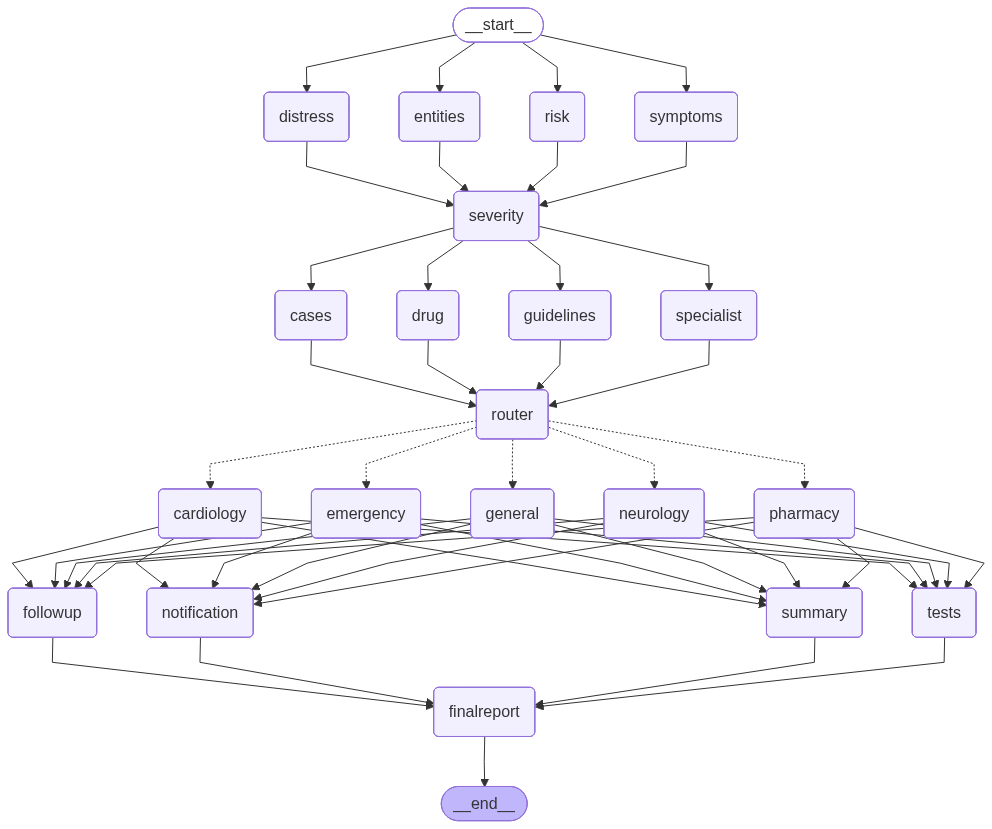

In [23]:
workflow

In [24]:
print("\n================ SPECIALIST RECOMMENDATION ================\n")
print(output["specialist_recommendations"])

print("\n================ ASSIGNED SPECIALIST ================\n")
print(output["assigned_specialist"])

print("\n================ TRIAGE SUMMARY ================\n")
print(output["triage_summary"])

print("\n================ FOLLOWUP PLAN ================\n")
print(output["followup_plan"])

print("\n================ DIAGNOSTIC TESTS ================\n")
print(output["diagnostic_tests"])

print("\n================ EMERGENCY NOTIFICATION ================\n")
print(output["emergency_notification"])

print("\n================ FINAL REPORT ================\n")
print(output["final_report"])


================ SPECIALIST RECOMMENDATION ================

Based on the patient's symptoms of chest pain, shortness of breath, sweating, and dizziness, along with a medical history that includes hypertension and diabetes, the best specialist department to seek care from is 

**Emergency Medicine.**

This department is equipped to handle acute conditions that could indicate a cardiac event, as the symptoms suggest a potential emergency. Prompt evaluation and intervention are critical in such cases.

================ ASSIGNED SPECIALIST ================

Emergency Medicine Team

================ TRIAGE SUMMARY ================

### Clinical Triage Summary

**Patient Symptoms:**
- Chest pain
- Shortness of breath
- Sweating
- Dizziness
- Duration: Symptoms since morning

---

### Detailed Severity Assessment

#### Severity Level
- **Risk Level**: **Critical**  
  The patient presents with symptoms that are highly indicative of an acute cardiac event or other life-threatening conditions